<>:41: SyntaxWarning: invalid escape sequence '\d'
<>:41: SyntaxWarning: invalid escape sequence '\d'
C:\Users\kartik\AppData\Local\Temp\ipykernel_9340\969294268.py:41: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


--- Dataset Overview ---
Dataset Shape: 8807 rows, 12 columns

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

--- Missing Values Count ---
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_add

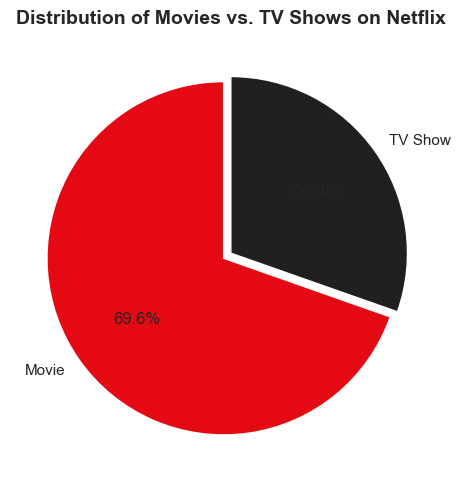

C:\Users\kartik\AppData\Local\Temp\ipykernel_9340\969294268.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')


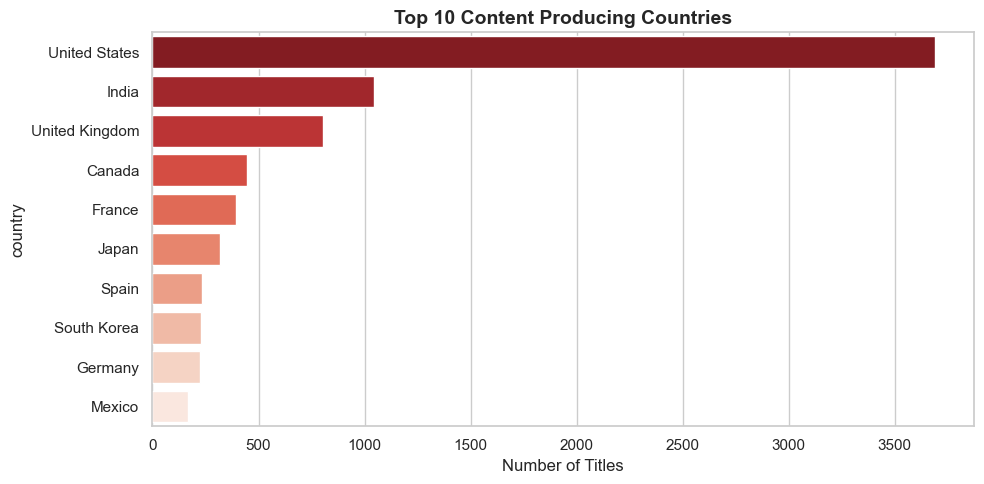

<Figure size 1100x500 with 0 Axes>

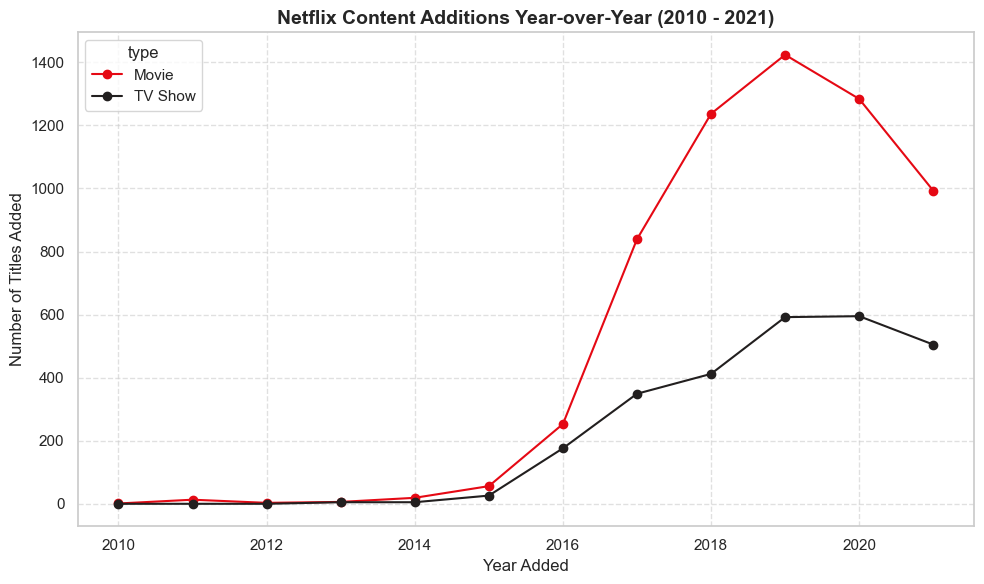

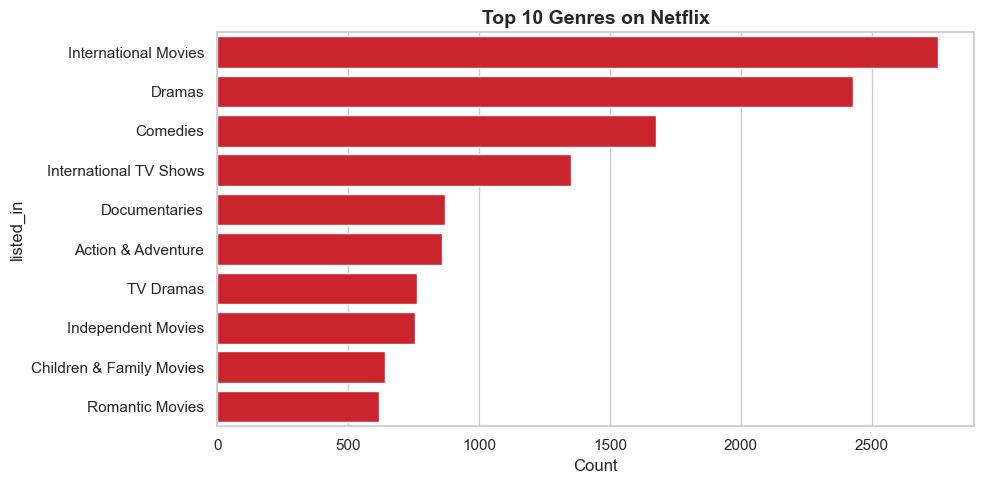

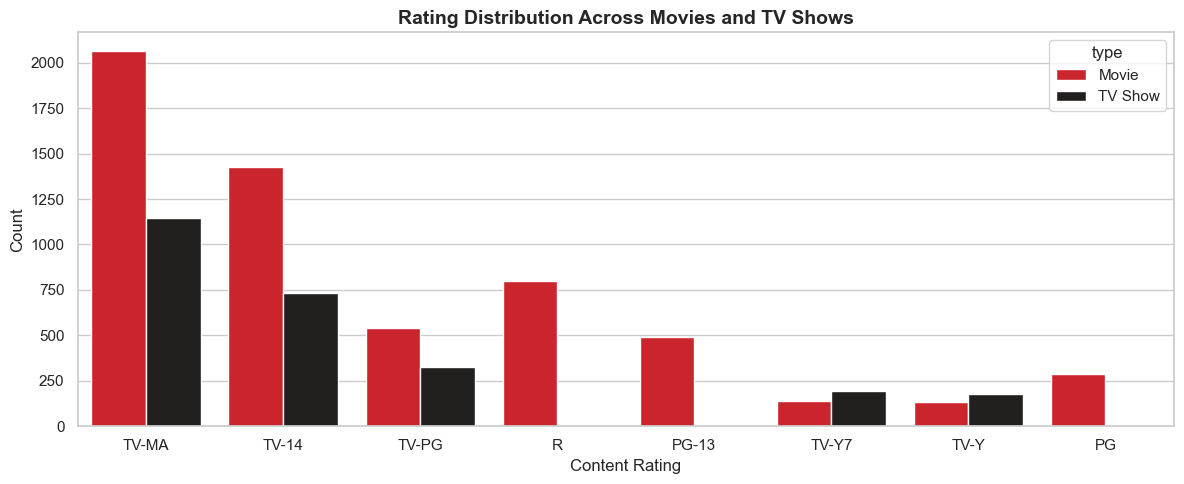

--- Key Analytical Insights ---
1. Movie Duration: Mean = 99.6 mins, Median = 98.0 mins
2. TV Show Seasons: Most common duration = 1 Season(s)
3. Most Frequent Director: Rajiv Chilaka
4. Peak Content Addition Year: 2019


In [1]:
# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('netflix_data.csv')

# Initial Data Inspection
print("--- Dataset Overview ---")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Column Info ---")
print(df.info())
print("\n--- Missing Values Count ---")
print(df.isnull().sum())


# ==========================================
# 2. DATA PREPROCESSING & CLEANING
# ==========================================
# Clean date column and extract temporal features
df['date_added'] = df['date_added'].str.strip()
df['date_added_clean'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added_clean'].dt.year
df['month_added'] = df['date_added_clean'].dt.month_name()

# Handle missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Separate duration numerical values for Movies (minutes) and TV Shows (seasons)
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract('([a-zA-Z]+)')

print("\n--- Preprocessing Complete ---")
print(f"Remaining Missing Values:\n{df.isnull().sum()}")


# ==========================================
# 3. EXPLORATORY DATA ANALYSIS & VISUALIZATION
# ==========================================

# Viz 1: Content Type Distribution
plt.figure(figsize=(7, 5))
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#E50914', '#221F1F'], startangle=90, explode=(0.05, 0))
plt.title('Distribution of Movies vs. TV Shows on Netflix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Viz 2: Top 10 Content Producing Countries
top_countries = (
    df[df['country'] != 'Unknown']['country']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 Content Producing Countries', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.show()

# Viz 3: Content Addition Growth Over Years
plt.figure(figsize=(11, 5))
yearly_type = df.groupby(['year_added', 'type']).size().unstack().fillna(0)
yearly_type = yearly_type[yearly_type.index >= 2010]  # Filter recent years

yearly_type.plot(kind='line', marker='o', color=['#E50914', '#221F1F'])
plt.title('Netflix Content Additions Year-over-Year (2010 - 2021)', fontsize=14, fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Viz 4: Top 10 Genres Breakdown
top_genres = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, color='#E50914')
plt.title('Top 10 Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Viz 5: Rating Distribution by Content Type
plt.figure(figsize=(12, 5))
top_ratings = df['rating'].value_counts().head(8).index
filtered_df = df[df['rating'].isin(top_ratings)]

sns.countplot(data=filtered_df, x='rating', hue='type', palette=['#E50914', '#221F1F'], order=top_ratings)
plt.title('Rating Distribution Across Movies and TV Shows', fontsize=14, fontweight='bold')
plt.xlabel('Content Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


# ==========================================
# 4. INSIGHTS & SUMMARY STATISTICS
# ==========================================
movie_df = df[df['type'] == 'Movie']
tv_df = df[df['type'] == 'TV Show']

print("--- Key Analytical Insights ---")
print(f"1. Movie Duration: Mean = {movie_df['duration_num'].mean():.1f} mins, Median = {movie_df['duration_num'].median():.1f} mins")
print(f"2. TV Show Seasons: Most common duration = {tv_df['duration_num'].mode()[0]:.0f} Season(s)")
print(f"3. Most Frequent Director: {df[df['director'] != 'Unknown']['director'].mode()[0]}")
print(f"4. Peak Content Addition Year: {int(df['year_added'].mode()[0])}")